#Project Understanding


In [1]:
# Exploratory Data Analysis
# ============================================================
# 1. IMPORT LIBRARY
# ============================================================

# Menghilangkan warning yang tidak diperlukan
import warnings
warnings.filterwarnings("ignore")

# Manipulasi data
import pandas as pd
import numpy as np

# Visualisasi data
import matplotlib.pyplot as plt
import seaborn as sns

# Analisis statistik
from scipy import stats

# Konfigurasi tampilan notebook
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

In [ ]:
# Membaca dataset
# 2. LOAD DATASET
# ============================================================

# Membaca dataset
%pip install openpyxl
# Membaca dataset dengan header berada pada baris ke-4 (indeks 3)
df = pd.read_excel("Dataset_Bersih.xlsx", header=3)

print("="*60)
print("Dataset berhasil dimuat")
print("="*60)


Note: you may need to restart the kernel to use updated packages.
Dataset berhasil dimuat



[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
# 3. DATASET OVERVIEW
# ============================================================

print("Ukuran Dataset")
print("-"*40)
print(f"Jumlah Baris  : {df.shape[0]}")
print(f"Jumlah Kolom  : {df.shape[1]}")

print("\nTampilan 5 Data Teratas")
display(df.head())

print("\nInformasi Dataset")
df.info()

print("\nStatistik Deskriptif")
display(df.describe().T)

Ukuran Dataset
----------------------------------------
Jumlah Baris  : 76
Jumlah Kolom  : 11

Tampilan 5 Data Teratas


,No,Kabupaten_Kota,Tahun,Stunting,Sanitasi,Air Bersih,Imunisasi,IKP,RLS,Pengeluaran,Kemiskinan
0,1,Kabupaten Bangkalan,2023,10.20,50.30,96.30,56.64,73.23,5.99,809398,19.35
1,2,Kabupaten Banyuwangi,2023,21.90,82.63,97.44,60.70,84.91,7.76,1304143,7.34
2,3,Kabupaten Blitar,2023,20.30,82.50,96.41,82.81,86.27,7.83,1053213,8.69
3,4,Kabupaten Bojonegoro,2023,14.10,92.63,97.59,64.94,85.40,7.45,1060818,12.18
4,5,Kabupaten Bondowoso,2023,17.00,57.41,94.43,50.68,75.50,6.36,1035467,13.34



Informasi Dataset
<class 'pandas.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   No              76 non-null     int64  
 1   Kabupaten_Kota  76 non-null     str    
 2   Tahun           76 non-null     int64  
 3   Stunting        68 non-null     float64
 4   Sanitasi        38 non-null     float64
 5   Air Bersih      38 non-null     float64
 6   Imunisasi       38 non-null     float64
 7   IKP             76 non-null     float64
 8   RLS             76 non-null     float64
 9   Pengeluaran     76 non-null     int64  
 10  Kemiskinan      76 non-null     float64
dtypes: float64(7), int64(3), str(1)
memory usage: 7.9 KB

Statistik Deskriptif


,count,mean,std,min,25%,50%,75%,max
No,76.00,38.50,22.08,1.00,19.75,38.50,57.25,76.00
Tahun,76.00,2023.50,0.50,2023.00,2023.00,2023.50,2024.00,2024.00
Stunting,68.00,16.86,6.71,1.60,11.70,16.80,20.45,35.40
Sanitasi,38.00,84.59,12.18,50.30,81.59,87.84,93.77,98.18
Air Bersih,38.00,96.12,4.81,79.26,95.69,97.61,98.84,100.00
Imunisasi,38.00,64.12,11.02,42.81,54.59,64.95,73.68,82.81
IKP,76.00,83.16,4.90,73.23,79.44,83.59,86.73,93.06
RLS,76.00,8.42,1.67,5.07,7.43,7.94,9.80,12.11
Pengeluaran,76.00,1312879.00,382074.92,740145.00,1053468.75,1177705.50,1531841.00,2602456.00
Kemiskinan,76.00,10.04,4.25,3.06,6.58,9.48,12.24,21.76


In [10]:
# ==========================================================
# 4. EXECUTIVE SUMMARY DATASET
# ==========================================================

# Kelompok variabel
identifier_columns = ["No", "Kabupaten_Kota", "Tahun"]

target_column = "Stunting"

feature_columns = [
    "Sanitasi",
    "Air Bersih",
    "Imunisasi",
    "IKP",
    "RLS",
    "Pengeluaran",
    "Kemiskinan"
]

# Ringkasan dataset
summary = pd.DataFrame({
    "Informasi": [
        "Jumlah Observasi",
        "Jumlah Variabel",
        "Variabel Numerik",
        "Variabel Kategorik",
        "Total Missing Value",
        "Jumlah Data Duplikat"
    ],
    "Nilai": [
        df.shape[0],
        df.shape[1],
        len(df.select_dtypes(include=np.number).columns),
        len(df.select_dtypes(exclude=np.number).columns),
        df.isna().sum().sum(),
        df.duplicated().sum()
    ]
})

display(summary)

print("\nDaftar Variabel Prediktor:")
print(feature_columns)

print("\nVariabel Target:")
print(target_column)

,Informasi,Nilai
0,Jumlah Observasi,76
1,Jumlah Variabel,11
2,Variabel Numerik,10
3,Variabel Kategorik,1
4,Total Missing Value,122
5,Jumlah Data Duplikat,0



Daftar Variabel Prediktor:
['Sanitasi', 'Air Bersih', 'Imunisasi', 'IKP', 'RLS', 'Pengeluaran', 'Kemiskinan']

Variabel Target:
Stunting


In [13]:
# 5. DATA QUALITY ASSESSMENT
# ==========================================================

# Ringkasan kualitas data
quality_summary = pd.DataFrame({
    "Tipe Data": df.dtypes.astype(str),
    "Missing Value": df.isnull().sum(),
    "Missing (%)": round(df.isnull().mean() * 100, 2),
    "Nilai Unik": df.nunique()
})

# Mengurutkan berdasarkan persentase missing value
quality_summary = quality_summary.sort_values(
    by="Missing (%)",
    ascending=False
)

print("=" * 70)
print("RINGKASAN KUALITAS DATA")
print("=" * 70)

display(quality_summary)

RINGKASAN KUALITAS DATA


,Tipe Data,Missing Value,Missing (%),Nilai Unik
Imunisasi,float64,38,50.00,38
Air Bersih,float64,38,50.00,37
Sanitasi,float64,38,50.00,37
Stunting,float64,8,10.53,59
Tahun,int64,0,0.00,2
No,int64,0,0.00,76
Kabupaten_Kota,str,0,0.00,38
IKP,float64,0,0.00,74
RLS,float64,0,0.00,70
Pengeluaran,int64,0,0.00,76


In [14]:
# Pemeriksaan Data Duplikat
# ==========================================================

duplicate_count = df.duplicated().sum()

print(f"Jumlah data duplikat : {duplicate_count}")

Jumlah data duplikat : 0


In [15]:
# Pemeriksaan Konsistensi Data Panel
# ==========================================================

duplicate_panel = df.duplicated(
    subset=["Kabupaten_Kota", "Tahun"]
).sum()

print(f"Jumlah duplikat kombinasi Kabupaten-Kota dan Tahun : {duplicate_panel}")

Jumlah duplikat kombinasi Kabupaten-Kota dan Tahun : 0


In [16]:
# Pemeriksaan Rentang Nilai / interval data
# ==========================================================

range_summary = pd.DataFrame({
    "Minimum": df[feature_columns + [target_column]].min(),
    "Maximum": df[feature_columns + [target_column]].max()
})

display(range_summary)

,Minimum,Maximum
Sanitasi,50.30,98.18
Air Bersih,79.26,100.00
Imunisasi,42.81,82.81
IKP,73.23,93.06
RLS,5.07,12.11
Pengeluaran,740145.00,2602456.00
Kemiskinan,3.06,21.76
Stunting,1.60,35.40


In [17]:
# Pemeriksaan Nilai Negatif
# ==========================================================

negative_summary = pd.DataFrame({
    "Jumlah Nilai Negatif": (df[feature_columns + [target_column]] < 0).sum()
})

display(negative_summary)

,Jumlah Nilai Negatif
Sanitasi,0
Air Bersih,0
Imunisasi,0
IKP,0
RLS,0
Pengeluaran,0
Kemiskinan,0
Stunting,0


In [18]:
# Pemeriksaan Variabel Persentase
# ==========================================================

percentage_columns = [
    "Stunting",
    "Sanitasi",
    "Air Bersih",
    "Imunisasi",
    "Kemiskinan"
]

percentage_check = pd.DataFrame({
    "Minimum": df[percentage_columns].min(),
    "Maximum": df[percentage_columns].max()
})

display(percentage_check)

,Minimum,Maximum
Stunting,1.60,35.40
Sanitasi,50.30,98.18
Air Bersih,79.26,100.00
Imunisasi,42.81,82.81
Kemiskinan,3.06,21.76


In [19]:
# 6. MISSING VALUE PATTERN ANALYSIS
# ==========================================================

missing_summary = pd.DataFrame({
    "Jumlah Missing": df.isnull().sum(),
    "Persentase (%)": round(df.isnull().mean() * 100, 2)
})

missing_summary = missing_summary[
    missing_summary["Jumlah Missing"] > 0
].sort_values(
    by="Persentase (%)",
    ascending=False
)

display(missing_summary)

,Jumlah Missing,Persentase (%)
Sanitasi,38,50.00
Air Bersih,38,50.00
Imunisasi,38,50.00
Stunting,8,10.53


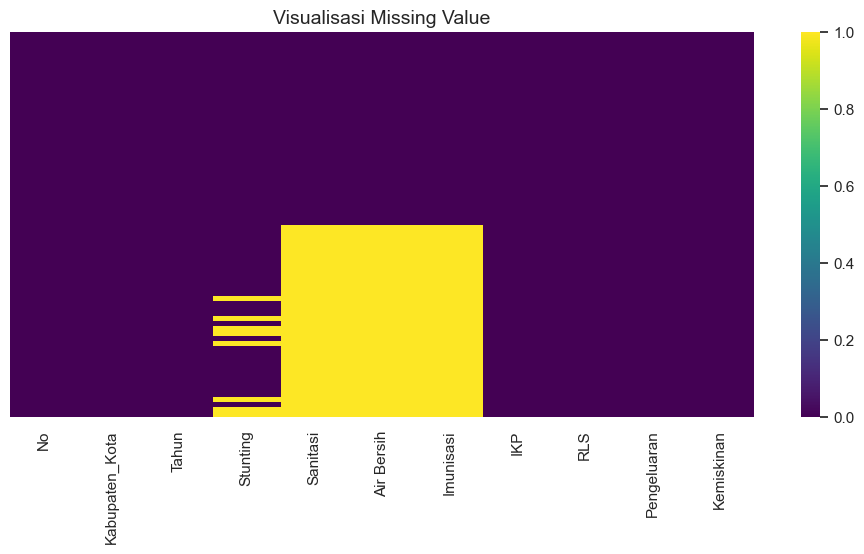

In [20]:
# Visualisasi Missing Value
# ==========================================================

plt.figure(figsize=(12,5))

sns.heatmap(
    df.isnull(),
    cmap="viridis",
    cbar=True,
    yticklabels=False
)

plt.title("Visualisasi Missing Value")

plt.show()

In [21]:
# Missing Value Berdasarkan Tahun
# ==========================================================

missing_by_year = (
    df
    .groupby("Tahun")
    .apply(lambda x: x.isnull().sum())
)

display(missing_by_year)

,No,Kabupaten_Kota,Stunting,Sanitasi,Air Bersih,Imunisasi,IKP,RLS,Pengeluaran,Kemiskinan
Tahun,,,,,,,,,,
2023,0,0,0,0,0,0,0,0,0,0
2024,0,0,8,38,38,38,0,0,0,0


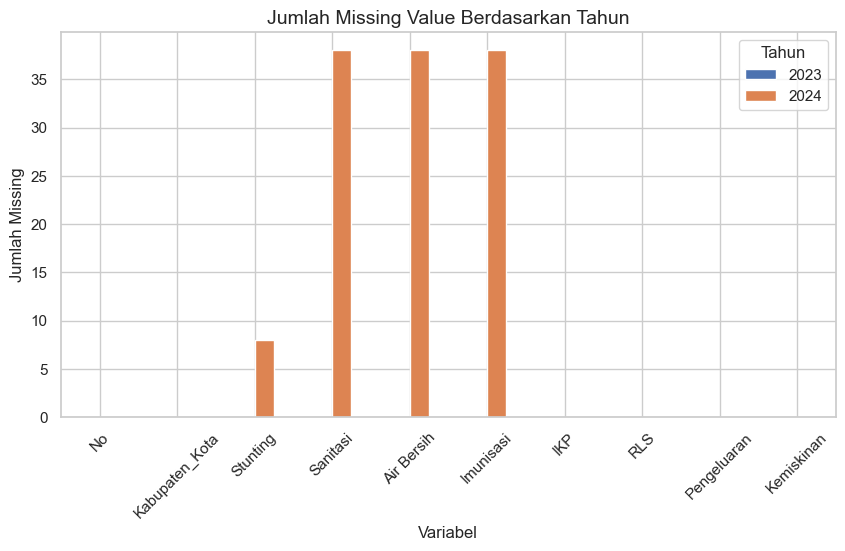

In [22]:
# Visualisasi Missing Value per Tahun
# ==========================================================

missing_by_year.T.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Jumlah Missing Value Berdasarkan Tahun")
plt.ylabel("Jumlah Missing")
plt.xlabel("Variabel")

plt.xticks(rotation=45)

plt.show()

In [23]:
# Missing Value per Kabupaten/Kota
# ==========================================================

missing_region = (
    df
    .groupby("Kabupaten_Kota")
    .apply(lambda x: x.isnull().sum().sum())
)

missing_region = missing_region.sort_values(
    ascending=False
)

display(missing_region)

Kabupaten_Kota
Kota Surabaya            4
Kota Probolinggo         4
Kabupaten Mojokerto      4
Kabupaten Probolinggo    4
Kabupaten Ponorogo       4
Kabupaten Pamekasan      4
Kota Mojokerto           4
Kabupaten Sidoarjo       4
Kabupaten Gresik         3
Kabupaten Bondowoso      3
Kabupaten Banyuwangi     3
Kabupaten Bangkalan      3
Kabupaten Bojonegoro     3
Kabupaten Blitar         3
Kabupaten Malang         3
Kabupaten Magetan        3
Kabupaten Madiun         3
Kabupaten Lumajang       3
Kabupaten Jember         3
Kabupaten Jombang        3
Kabupaten Kediri         3
Kabupaten Lamongan       3
Kabupaten Pasuruan       3
Kabupaten Nganjuk        3
Kabupaten Ngawi          3
Kabupaten Pacitan        3
Kabupaten Trenggalek     3
Kabupaten Sampang        3
Kabupaten Situbondo      3
Kabupaten Sumenep        3
Kota Batu                3
Kabupaten Tulungagung    3
Kabupaten Tuban          3
Kota Blitar              3
Kota Malang              3
Kota Madiun              3
Kota Kediri  

In [25]:
# Kabupaten/Kota dengan Missing Target (prevalensi stunting)
# ==========================================================

missing_target = df[df[target_column].isnull()][["Kabupaten_Kota", "Tahun"]]

print(f"Jumlah observasi dengan missing target : {len(missing_target)}")

display(missing_target)

Jumlah observasi dengan missing target : 8


,Kabupaten_Kota,Tahun
52,Kabupaten Mojokerto,2024
56,Kabupaten Pamekasan,2024
58,Kabupaten Ponorogo,2024
59,Kabupaten Probolinggo,2024
61,Kabupaten Sidoarjo,2024
72,Kota Mojokerto,2024
74,Kota Probolinggo,2024
75,Kota Surabaya,2024


Output tersebut menunjukkan bahwa hanya terdapat 8 observasi yang belum memiliki nilai target Stunting dan seluruhnya berada pada tahun 2024.

Ini sangat penting karena membuktikan bahwa:

Missing target tidak tersebar secara acak (MCAR).
Missing juga bukan karena kesalahan input data.
Missing muncul karena data resmi prevalensi stunting tahun 2024 untuk beberapa daerah belum dipublikasikan.

Dengan kata lain, ini adalah missing by design / unavailable data, bukan data rusak

In [26]:
# Ringkasan Pola Missing Value
# ==========================================================

imputation_plan = pd.DataFrame({
    "Variabel": [
        "Sanitasi",
        "Air Bersih",
        "Imunisasi",
        "Stunting"
    ],
    "Jumlah Missing": [
        df["Sanitasi"].isnull().sum(),
        df["Air Bersih"].isnull().sum(),
        df["Imunisasi"].isnull().sum(),
        df["Stunting"].isnull().sum()
    ],
    "Pola Missing": [
        "Seluruh tahun 2024",
        "Seluruh tahun 2024",
        "Seluruh tahun 2024",
        "Sebagian tahun 2024"
    ],
    "Rencana Preprocessing": [
        "Forward Fill",
        "Forward Fill",
        "Growth Ratio / Forward Fill (akan divalidasi)",
        "KNN Imputation"
    ]
})

display(imputation_plan)

,Variabel,Jumlah Missing,Pola Missing,Rencana Preprocessing
0,Sanitasi,38,Seluruh tahun 2024,Forward Fill
1,Air Bersih,38,Seluruh tahun 2024,Forward Fill
2,Imunisasi,38,Seluruh tahun 2024,Growth Ratio / Forward Fill (akan divalidasi)
3,Stunting,8,Sebagian tahun 2024,KNN Imputation


In [27]:
# 7. DESCRIPTIVE STATISTICS
# ==========================================================

# Statistik deskriptif variabel penelitian
descriptive_stats = df[feature_columns + [target_column]].describe().T

display(descriptive_stats)

,count,mean,std,min,25%,50%,75%,max
Sanitasi,38.00,84.59,12.18,50.30,81.59,87.84,93.77,98.18
Air Bersih,38.00,96.12,4.81,79.26,95.69,97.61,98.84,100.00
Imunisasi,38.00,64.12,11.02,42.81,54.59,64.95,73.68,82.81
IKP,76.00,83.16,4.90,73.23,79.44,83.59,86.73,93.06
RLS,76.00,8.42,1.67,5.07,7.43,7.94,9.80,12.11
Pengeluaran,76.00,1312879.00,382074.92,740145.00,1053468.75,1177705.50,1531841.00,2602456.00
Kemiskinan,76.00,10.04,4.25,3.06,6.58,9.48,12.24,21.76
Stunting,68.00,16.86,6.71,1.60,11.70,16.80,20.45,35.40


In [28]:
# Statistika deskriptif Tambahan
# ==========================================================

additional_stats = pd.DataFrame({
    "Mean": df[feature_columns + [target_column]].mean(),
    "Median": df[feature_columns + [target_column]].median(),
    "Std Dev": df[feature_columns + [target_column]].std(),
    "Variance": df[feature_columns + [target_column]].var(),
    "Skewness": df[feature_columns + [target_column]].skew(),
    "Kurtosis": df[feature_columns + [target_column]].kurt()
})

display(additional_stats)

,Mean,Median,Std Dev,Variance,Skewness,Kurtosis
Sanitasi,84.59,87.84,12.18,148.43,-1.25,0.91
Air Bersih,96.12,97.61,4.81,23.15,-2.55,6.41
Imunisasi,64.12,64.95,11.02,121.53,-0.15,-0.96
IKP,83.16,83.59,4.90,24.02,0.03,-0.78
RLS,8.42,7.94,1.67,2.79,0.30,-0.62
Pengeluaran,1312879.00,1177705.50,382074.92,145981242600.99,1.14,1.26
Kemiskinan,10.04,9.48,4.25,18.04,0.70,0.26
Stunting,16.86,16.80,6.71,44.99,0.47,0.31


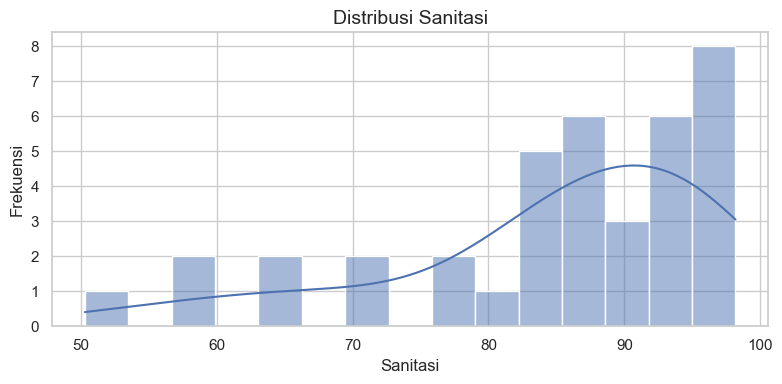

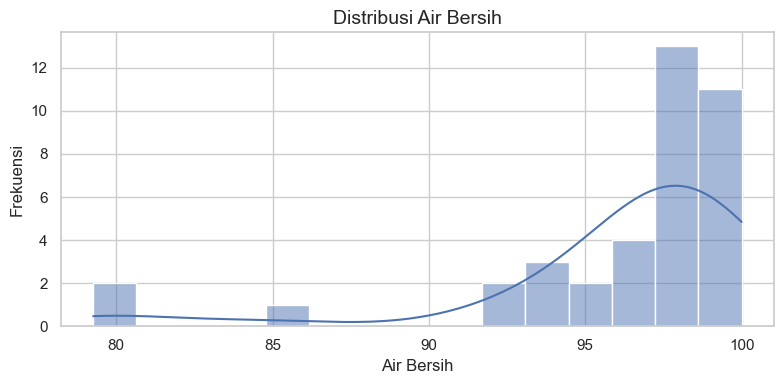

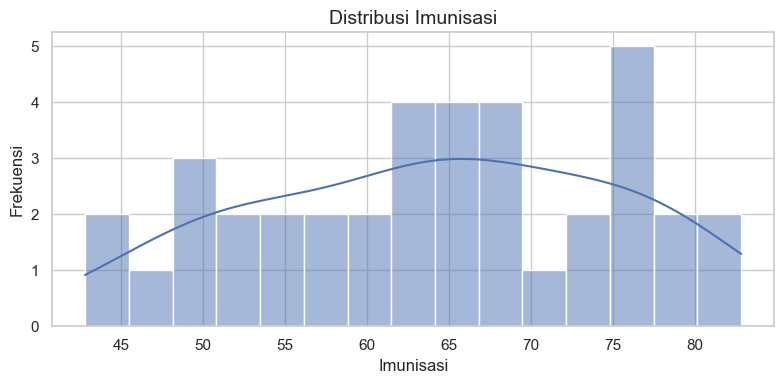

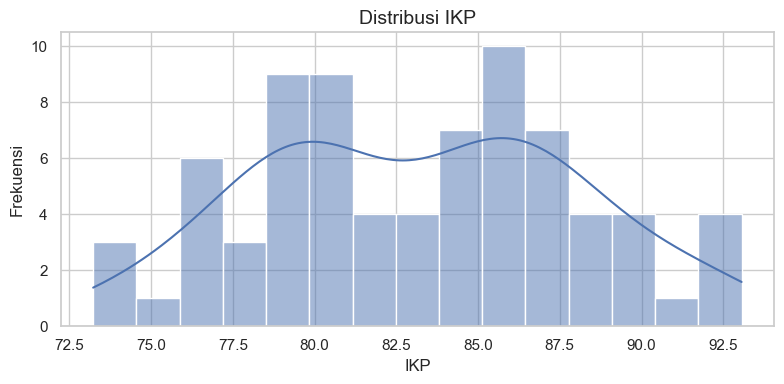

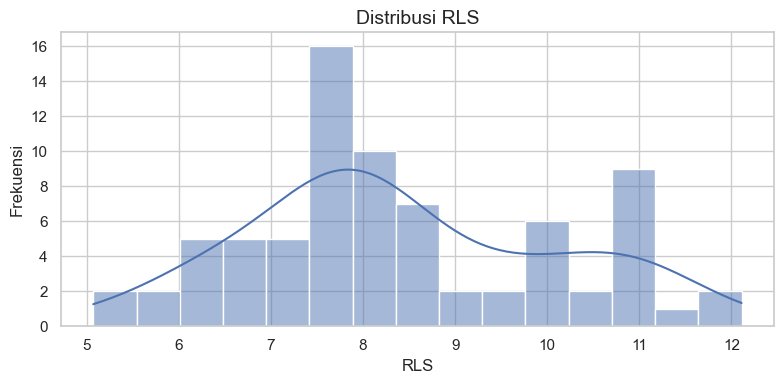

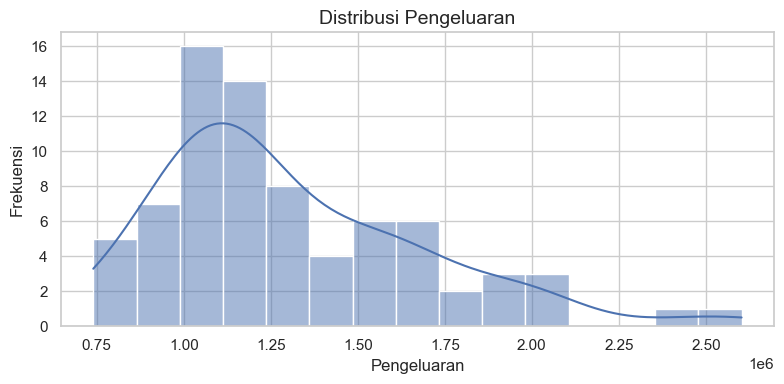

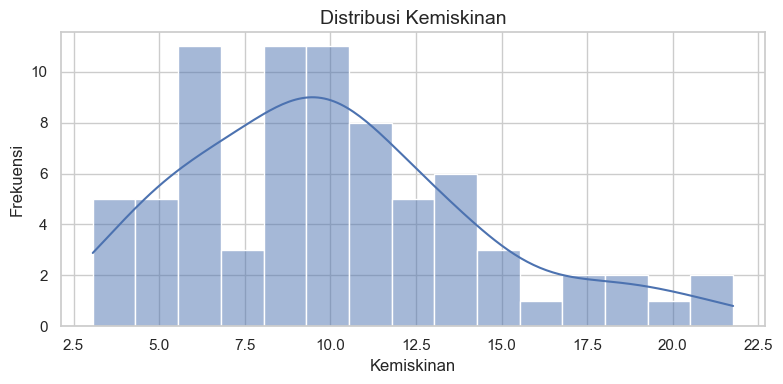

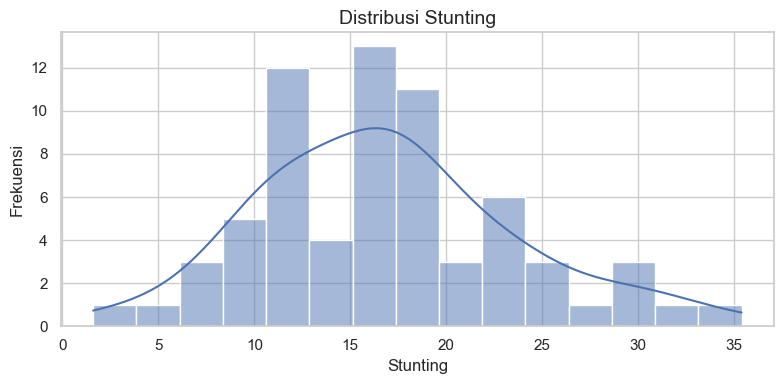

In [ ]:
# Distribusi masing - masing variabel
# ==========================================================

for col in feature_columns + [target_column]:

    plt.figure(figsize=(8,4))

    sns.histplot(
        data=df,
        x=col,
        bins=15,
        kde=True
    )

    plt.title(f"Distribusi {col}")

    plt.xlabel(col)

    plt.ylabel("Frekuensi")

    plt.tight_layout()

    plt.show()

### Interpretasi Skewness

Skewness merupakan ukuran statistik yang digunakan untuk mengetahui tingkat kemencengan (kemiringan) distribusi data terhadap distribusi normal. Nilai skewness membantu mengidentifikasi apakah suatu variabel memiliki distribusi yang simetris atau cenderung memiliki ekor distribusi yang lebih panjang pada salah satu sisi.

Kriteria interpretasi yang digunakan adalah sebagai berikut:

- **|Skewness| < 0,5** → Distribusi **simetris**, artinya data relatif seimbang dan mendekati distribusi normal.
- **0,5 ≤ |Skewness| < 1** → Distribusi **moderately skewed**, artinya data memiliki tingkat kemencengan sedang sehingga masih cukup representatif untuk dianalisis tanpa transformasi khusus.
- **|Skewness| ≥ 1** → Distribusi **highly skewed**, artinya data memiliki tingkat kemencengan yang tinggi sehingga berpotensi memengaruhi proses pemodelan. Variabel dengan kondisi ini menjadi kandidat untuk dilakukan transformasi data, seperti transformasi logaritmik (`log1p`), apabila diperlukan pada tahap preprocessing.

In [37]:
# hasil distribusi kemudian di intepretasikan berdasarkan Skewness beserta rekomendasi preprocessing jika diperlukan
# ==========================================================

distribution_summary = pd.DataFrame({
    "Skewness": df[feature_columns + [target_column]].skew()
})

# Fungsi interpretasi skewness
def interpret_skewness(skew):
    if abs(skew) < 0.5:
        return "Simetris"
    elif abs(skew) < 1:
        return "Moderately Skewed"
    else:
        return "Highly Skewed"

distribution_summary["Interpretasi"] = (
    distribution_summary["Skewness"]
    .apply(interpret_skewness)
)

# Fungsi rekomendasi preprocessing
def preprocessing_recommendation(variable):

    if variable == "Pengeluaran":
        return "Transformasi log1p"

    return "Tidak perlu transformasi"

# Fungsi alasan
def recommendation_reason(variable):

    if variable == "Pengeluaran":
        return "Distribusi sangat menceng ke kanan dan memiliki rentang nilai yang lebar."

    elif variable in ["Sanitasi","Air Bersih"]:
        return "Meskipun highly skewed, variabel berupa persentase sehingga distribusinya masih wajar."

    elif variable == "Kemiskinan":
        return "Kemencengan masih tergolong moderat sehingga tidak memerlukan transformasi."

    else:
        return "Distribusi relatif simetris sehingga dapat digunakan dalam bentuk asli."

distribution_summary["Rekomendasi"] = [
    preprocessing_recommendation(col)
    for col in distribution_summary.index
]

distribution_summary["Alasan"] = [
    recommendation_reason(col)
    for col in distribution_summary.index
]

distribution_summary = distribution_summary.style\
    .format({"Skewness": "{:.2f}"})\
    .set_caption("Interpretasi Skewness dan Rekomendasi Preprocessing")

display(distribution_summary)

,Skewness,Interpretasi,Rekomendasi,Alasan
Sanitasi,-1.25,Highly Skewed,Tidak perlu transformasi,"Meskipun highly skewed, variabel berupa persentase sehingga distribusinya masih wajar."
Air Bersih,-2.55,Highly Skewed,Tidak perlu transformasi,"Meskipun highly skewed, variabel berupa persentase sehingga distribusinya masih wajar."
Imunisasi,-0.15,Simetris,Tidak perlu transformasi,Distribusi relatif simetris sehingga dapat digunakan dalam bentuk asli.
IKP,0.03,Simetris,Tidak perlu transformasi,Distribusi relatif simetris sehingga dapat digunakan dalam bentuk asli.
RLS,0.30,Simetris,Tidak perlu transformasi,Distribusi relatif simetris sehingga dapat digunakan dalam bentuk asli.
Pengeluaran,1.14,Highly Skewed,Transformasi log1p,Distribusi sangat menceng ke kanan dan memiliki rentang nilai yang lebar.
Kemiskinan,0.70,Moderately Skewed,Tidak perlu transformasi,Kemencengan masih tergolong moderat sehingga tidak memerlukan transformasi.
Stunting,0.47,Simetris,Tidak perlu transformasi,Distribusi relatif simetris sehingga dapat digunakan dalam bentuk asli.


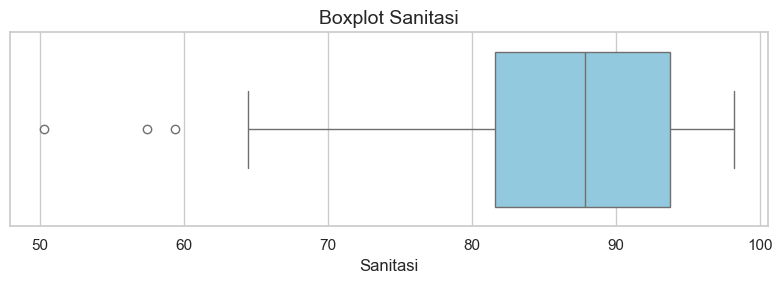

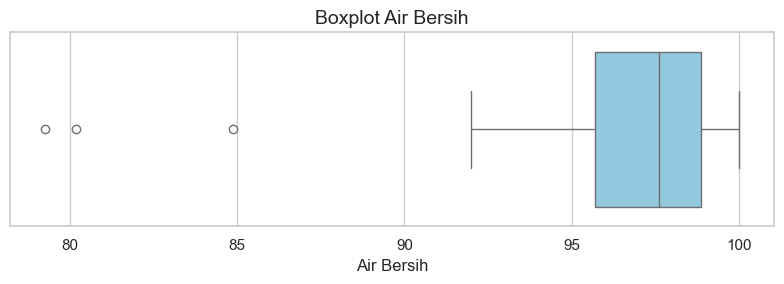

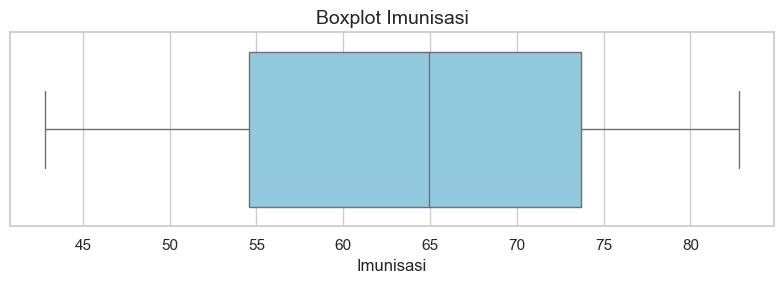

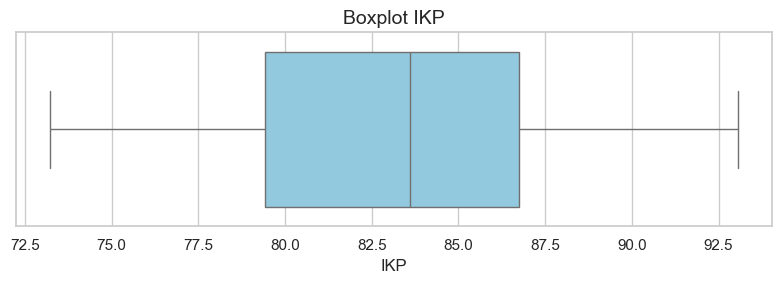

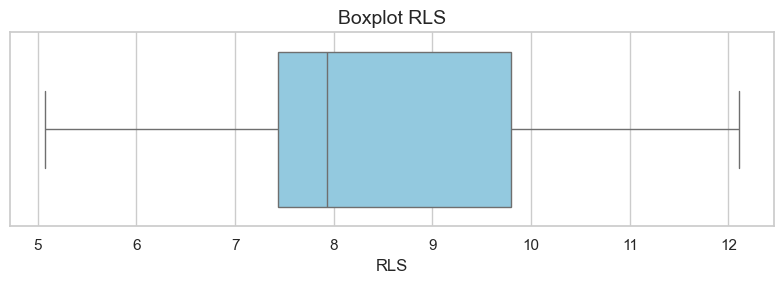

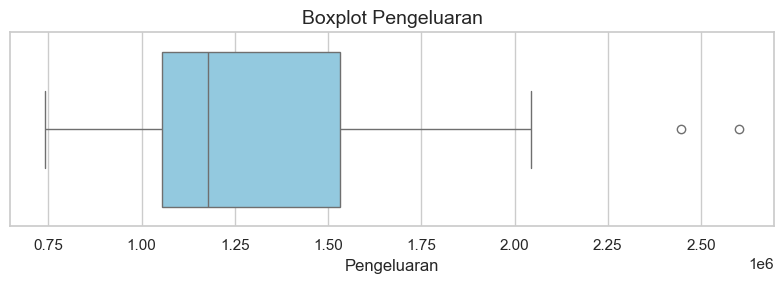

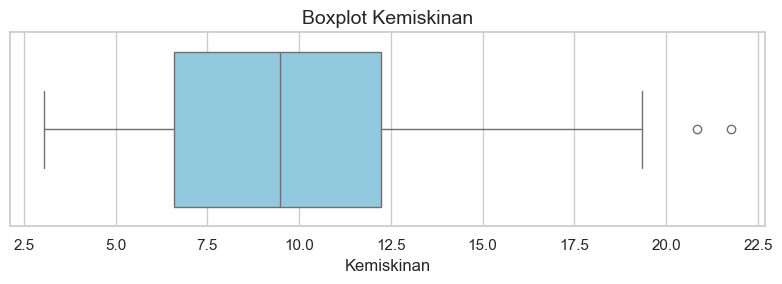

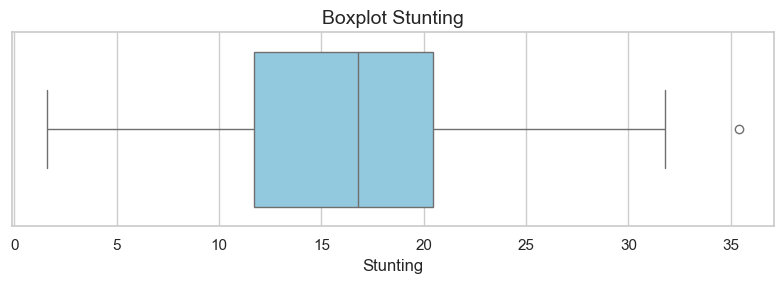

In [38]:
# 9. OUTLIER ANALYSIS
# ==========================================================

for col in feature_columns + [target_column]:

    plt.figure(figsize=(8,3))

    sns.boxplot(
        x=df[col],
        color="skyblue"
    )

    plt.title(f"Boxplot {col}")

    plt.xlabel(col)

    plt.tight_layout()

    plt.show()

In [39]:
# Menghitung Outlier Menggunakan Metode IQR
# ==========================================================

outlier_result = []

for col in feature_columns + [target_column]:

    Q1 = df[col].quantile(0.25)

    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    total = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_result.append({
        "Variabel": col,
        "Jumlah Outlier": total,
        "Batas Bawah": round(lower,2),
        "Batas Atas": round(upper,2)
    })

outlier_summary = pd.DataFrame(outlier_result)

display(outlier_summary)

,Variabel,Jumlah Outlier,Batas Bawah,Batas Atas
0,Sanitasi,3,63.31,112.05
1,Air Bersih,3,90.97,103.57
2,Imunisasi,0,25.94,102.33
3,IKP,0,68.49,97.68
4,RLS,0,3.88,13.35
5,Pengeluaran,2,335910.38,2249399.38
6,Kemiskinan,2,-1.90,20.72
7,Stunting,1,-1.43,33.58


In [40]:
# Menampilkan Observasi Outlier
# ==========================================================

for col in feature_columns + [target_column]:

    Q1 = df[col].quantile(0.25)

    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    outlier = df[
        (df[col] < lower) |
        (df[col] > upper)
    ][["Kabupaten_Kota","Tahun",col]]

    if len(outlier)>0:

        print("="*70)

        print(f"Outlier pada variabel {col}")

        display(outlier)

Outlier pada variabel Sanitasi


,Kabupaten_Kota,Tahun,Sanitasi
0,Kabupaten Bangkalan,2023,50.30
4,Kabupaten Bondowoso,2023,57.41
24,Kabupaten Situbondo,2023,59.37


Outlier pada variabel Air Bersih


,Kabupaten_Kota,Tahun,Air Bersih
9,Kabupaten Lamongan,2023,79.26
17,Kabupaten Pacitan,2023,80.19
26,Kabupaten Trenggalek,2023,84.87


Outlier pada variabel Pengeluaran


,Kabupaten_Kota,Tahun,Pengeluaran
37,Kota Surabaya,2023,2445917
75,Kota Surabaya,2024,2602456


Outlier pada variabel Kemiskinan


,Kabupaten_Kota,Tahun,Kemiskinan
22,Kabupaten Sampang,2023,21.76
60,Kabupaten Sampang,2024,20.83


Outlier pada variabel Stunting


,Kabupaten_Kota,Tahun,Stunting
21,Kabupaten Probolinggo,2023,35.40


In [41]:
# Rekomendasi Penanganan Outlier
# ==========================================================

recommendation = []

for _, row in outlier_summary.iterrows():

    if row["Jumlah Outlier"] == 0:

        rec = "Tidak diperlukan penanganan"

    elif row["Variabel"] == "Pengeluaran":

        rec = "Dipertahankan, akan distabilkan menggunakan transformasi log1p"

    else:

        rec = "Dipertahankan, diduga merupakan variasi alami antar kabupaten"

    recommendation.append(rec)

outlier_summary["Rekomendasi"] = recommendation

display(outlier_summary)

,Variabel,Jumlah Outlier,Batas Bawah,Batas Atas,Rekomendasi
0,Sanitasi,3,63.31,112.05,"Dipertahankan, diduga merupakan variasi alami ..."
1,Air Bersih,3,90.97,103.57,"Dipertahankan, diduga merupakan variasi alami ..."
2,Imunisasi,0,25.94,102.33,Tidak diperlukan penanganan
3,IKP,0,68.49,97.68,Tidak diperlukan penanganan
4,RLS,0,3.88,13.35,Tidak diperlukan penanganan
5,Pengeluaran,2,335910.38,2249399.38,"Dipertahankan, akan distabilkan menggunakan tr..."
6,Kemiskinan,2,-1.90,20.72,"Dipertahankan, diduga merupakan variasi alami ..."
7,Stunting,1,-1.43,33.58,"Dipertahankan, diduga merupakan variasi alami ..."


### Interpretasi Analisis Outlier

Analisis outlier dilakukan menggunakan metode **Interquartile Range (IQR)** dengan batas bawah **Q1 − 1,5 × IQR** dan batas atas **Q3 + 1,5 × IQR**. Observasi yang berada di luar rentang tersebut dikategorikan sebagai outlier.

Berdasarkan hasil analisis, diperoleh bahwa **Sanitasi** dan **Air Bersih** masing-masing memiliki **3 observasi outlier**, **Pengeluaran** dan **Kemiskinan** masing-masing memiliki **2 observasi outlier**, sedangkan **Stunting** memiliki **1 observasi outlier**. Sementara itu, variabel **Imunisasi**, **Indeks Ketahanan Pangan (IKP)**, dan **Rata-rata Lama Sekolah (RLS)** tidak menunjukkan adanya outlier.

Penelusuran lebih lanjut menunjukkan bahwa outlier tersebut masih merepresentasikan kondisi nyata antarwilayah di Provinsi Jawa Timur, sehingga **tidak dikategorikan sebagai kesalahan pencatatan (data entry error)**.

- Outlier pada **Sanitasi** ditemukan pada **Kabupaten Bangkalan**, **Kabupaten Bondowoso**, dan **Kabupaten Situbondo** yang memiliki cakupan sanitasi relatif lebih rendah dibandingkan mayoritas kabupaten/kota lainnya.

- Outlier pada **Air Bersih** ditemukan pada **Kabupaten Lamongan**, **Kabupaten Pacitan**, dan **Kabupaten Trenggalek**, yang memiliki persentase akses air bersih lebih rendah dibandingkan daerah lainnya.

- Outlier pada **Pengeluaran** hanya ditemukan pada **Kota Surabaya** untuk tahun **2023** dan **2024**. Kondisi ini masih wajar karena Kota Surabaya merupakan pusat ekonomi Provinsi Jawa Timur sehingga memiliki rata-rata pengeluaran per kapita yang jauh lebih tinggi dibandingkan kabupaten/kota lainnya.

- Outlier pada **Kemiskinan** ditemukan pada **Kabupaten Sampang** pada tahun **2023** dan **2024**, yang menunjukkan tingkat kemiskinan lebih tinggi dibandingkan mayoritas wilayah lain di Jawa Timur.

- Outlier pada variabel **Stunting** ditemukan pada **Kabupaten Probolinggo** tahun **2023** dengan prevalensi sebesar **35,40%**, yang menunjukkan bahwa daerah tersebut memiliki tingkat stunting jauh di atas sebagian besar kabupaten/kota lainnya.

Berdasarkan hasil tersebut, **seluruh outlier dipertahankan** karena mencerminkan karakteristik nyata masing-masing wilayah dan merupakan informasi yang penting dalam proses pemodelan. Tidak dilakukan penghapusan outlier agar model tetap mampu mempelajari variasi kondisi antar kabupaten/kota di Provinsi Jawa Timur.

Secara khusus, variabel **Pengeluaran** tetap akan diberikan **transformasi `log1p`** pada tahap preprocessing. Keputusan ini bukan karena keberadaan outlier semata, melainkan untuk mengurangi kemencengan distribusi (*right-skewed*) dan menstabilkan rentang nilai yang relatif lebar sehingga proses pembelajaran model menjadi lebih optimal.

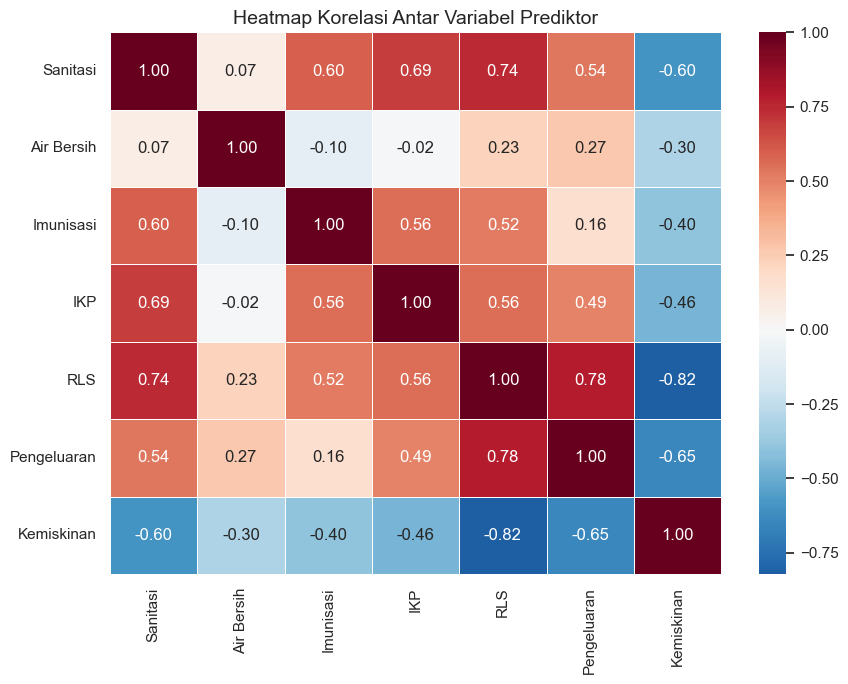

In [44]:
# PIPELINE 10
# CORRELATION STRUCTURE ANALYSIS
#tujuannya : mengetahui hubungan antar variabel prediktor, bukan dengan target/ respon
# ==========================================================

feature_corr = df[feature_columns].corr(method='pearson')

plt.figure(figsize=(9,7))

sns.heatmap(
    feature_corr,
    annot=True,
    cmap='RdBu_r',
    center=0,
    fmt='.2f',
    linewidths=0.5
)

plt.title("Heatmap Korelasi Antar Variabel Prediktor")

plt.tight_layout()
plt.show()

In [46]:
# Daftar Korelasi Antar Variabel Prediktor
# ==========================================================

corr_pairs = (
    feature_corr
    .unstack()
    .reset_index()
)

corr_pairs.columns = [
    "Variabel 1",
    "Variabel 2",
    "Koefisien Korelasi"
]

# Menghapus pasangan variabel yang sama
corr_pairs = corr_pairs[
    corr_pairs["Variabel 1"] != corr_pairs["Variabel 2"]
]

# Menghapus pasangan duplikat
corr_pairs["Pair"] = corr_pairs.apply(
    lambda x: tuple(sorted([x["Variabel 1"], x["Variabel 2"]])),
    axis=1
)

corr_pairs = corr_pairs.drop_duplicates(
    subset="Pair"
).drop(columns="Pair")

# Mengurutkan berdasarkan nilai absolut korelasi
corr_pairs = corr_pairs.sort_values(
    by="Koefisien Korelasi",
    key=lambda x: np.abs(x),
    ascending=False
).reset_index(drop=True)

display(corr_pairs)

,Variabel 1,Variabel 2,Koefisien Korelasi
0,RLS,Kemiskinan,-0.82
1,RLS,Pengeluaran,0.78
2,Sanitasi,RLS,0.74
3,Sanitasi,IKP,0.69
4,Pengeluaran,Kemiskinan,-0.65
5,Sanitasi,Imunisasi,0.60
6,Sanitasi,Kemiskinan,-0.60
7,Imunisasi,IKP,0.56
8,IKP,RLS,0.56
9,Sanitasi,Pengeluaran,0.54


In [47]:
# Interpretasi Kekuatan Korelasi
# ==========================================================

def interpretasi_korelasi(r):
    r = abs(r)

    if r >= 0.80:
        return "Sangat Kuat"

    elif r >= 0.60:
        return "Kuat"

    elif r >= 0.40:
        return "Sedang"

    elif r >= 0.20:
        return "Lemah"

    else:
        return "Sangat Lemah"

corr_pairs["Kategori"] = corr_pairs[
    "Koefisien Korelasi"
].apply(interpretasi_korelasi)

display(corr_pairs)

,Variabel 1,Variabel 2,Koefisien Korelasi,Kategori
0,RLS,Kemiskinan,-0.82,Sangat Kuat
1,RLS,Pengeluaran,0.78,Kuat
2,Sanitasi,RLS,0.74,Kuat
3,Sanitasi,IKP,0.69,Kuat
4,Pengeluaran,Kemiskinan,-0.65,Kuat
5,Sanitasi,Imunisasi,0.60,Sedang
6,Sanitasi,Kemiskinan,-0.60,Sedang
7,Imunisasi,IKP,0.56,Sedang
8,IKP,RLS,0.56,Sedang
9,Sanitasi,Pengeluaran,0.54,Sedang


### Interpretasi Analisis Korelasi Antar Variabel

Analisis korelasi Pearson dilakukan untuk memperoleh gambaran awal mengenai hubungan linear antar variabel prediktor sebelum proses preprocessing. Tujuan utama analisis ini bukan untuk mengidentifikasi faktor yang paling memengaruhi prevalensi stunting, melainkan untuk mengevaluasi struktur hubungan antar fitur serta mendeteksi adanya potensi multikolinearitas.

Berdasarkan hasil analisis, beberapa pasangan variabel menunjukkan hubungan yang cukup kuat, di antaranya **Rata-rata Lama Sekolah (RLS) dengan Kemiskinan (-0,82)**, **RLS dengan Pengeluaran (0,78)**, serta **Sanitasi dengan RLS (0,74)**. Kondisi ini menunjukkan bahwa beberapa indikator sosial ekonomi memiliki keterkaitan yang tinggi sehingga perlu dievaluasi lebih lanjut sebelum proses pemodelan dilakukan.

Perlu diperhatikan bahwa analisis korelasi pada tahap EDA masih dilakukan menggunakan dataset yang **belum melalui proses imputasi missing value**. Akibatnya, koefisien korelasi pada variabel yang masih memiliki data hilang (Sanitasi, Air Bersih, Imunisasi, dan sebagian Stunting) dihitung berdasarkan jumlah observasi yang berbeda (*pairwise complete observation*). Oleh karena itu, hasil korelasi pada tahap ini bersifat **eksploratif** dan belum digunakan sebagai dasar pengambilan keputusan dalam pemilihan fitur.

Pada tahap **preprocessing**, beberapa langkah lanjutan akan dilakukan untuk menghasilkan dataset yang lebih representatif, yaitu:

- Melakukan **Forward Fill** pada variabel **Sanitasi** dan **Air Bersih** karena data tahun 2024 belum dipublikasikan dan kedua indikator tersebut merupakan indikator infrastruktur yang cenderung berubah secara bertahap.
- Melakukan **Growth Ratio Imputation** pada variabel **Imunisasi** agar perubahan cakupan imunisasi antar tahun tetap dapat direpresentasikan secara lebih realistis.
- Melakukan **KNN Imputation** pada variabel target **Stunting** yang masih memiliki delapan nilai hilang pada tahun 2024 sehingga estimasi dilakukan berdasarkan kemiripan karakteristik antar kabupaten/kota.
- Melakukan **transformasi log1p** pada variabel **Pengeluaran** untuk mengurangi tingkat kemencengan distribusi (right-skewed).
- Menghitung kembali **korelasi antar variabel**, **korelasi terhadap target**, serta **Variance Inflation Factor (VIF)** menggunakan dataset yang telah lengkap sehingga hasil analisis menjadi lebih akurat dan dapat digunakan sebagai dasar proses pemodelan machine learning.

Dengan demikian, analisis korelasi pada tahap EDA berfungsi sebagai eksplorasi awal terhadap karakteristik hubungan antar variabel, sedangkan analisis korelasi setelah preprocessing akan menjadi acuan utama dalam evaluasi fitur sebelum pembangunan model machine learning.

**Pipeline 11 yaitu temporal analysis**
Tujuan : Melihat karakteristik dataset berdasarkan tahun (2023 dan 2024) untuk memastikan bahwa missing value memang berasal dari data tahun 2024 serta membandingkan gambaran umum antar tahun.

In [ ]:
# statistik deskriptif per tahun
# ==========================================================

summary_year = (
    df
    .groupby("Tahun")[feature_columns + [target_column]]
    .agg(["mean", "median", "std"])
    .round(2)
)

display(summary_year)

Sanitasi              Air Bersih             Imunisasi               \
          mean median   std       mean median  std      mean median   std   
Tahun                                                                       
2023     84.59  87.84 12.18      96.12  97.61 4.81     64.12  64.95 11.02   
2024       NaN    NaN   NaN        NaN    NaN  NaN       NaN    NaN   NaN   

        IKP              RLS             Pengeluaran                       \
       mean median  std mean median  std        mean     median       std   
Tahun                                                                       
2023  82.46  82.71 4.98 8.38   7.93 1.66  1301429.45 1177705.50 384087.62   
2024  83.86  84.32 4.79 8.46   8.06 1.70  1324328.55 1176348.50 384857.57   

      Kemiskinan             Stunting              
            mean median  std     mean median  std  
Tahun                                              
2023       10.29   9.66 4.32    17.70  16.90 7.10  
2024        9.78   9.22 4.21    15.79  14.45 6.12

In [49]:
# Missing Value Berdasarkan Tahun
# ==========================================================

missing_per_year = (
    df
    .groupby("Tahun")
    .apply(lambda x: x.isnull().sum())
    .T
)

missing_per_year.columns = [
    f"Tahun {col}"
    for col in missing_per_year.columns
]

display(missing_per_year)

,Tahun 2023,Tahun 2024
No,0,0
Kabupaten_Kota,0,0
Stunting,0,8
Sanitasi,0,38
Air Bersih,0,38
Imunisasi,0,38
IKP,0,0
RLS,0,0
Pengeluaran,0,0
Kemiskinan,0,0


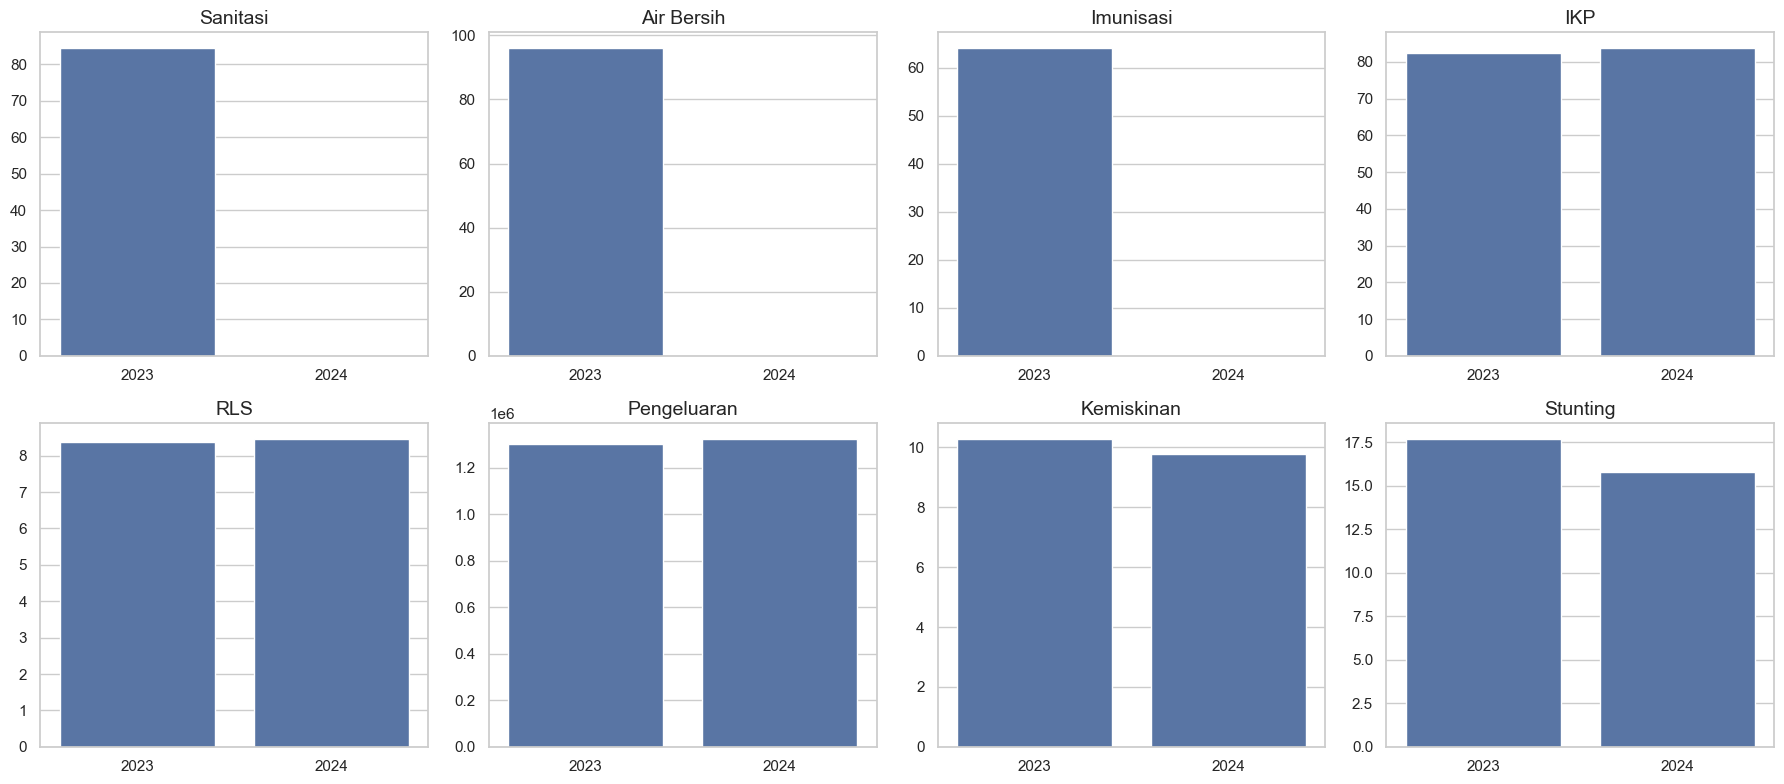

In [50]:
# Visualisasi Perbandingan Rata-rata per Tahun
# ==========================================================

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

axes = axes.flatten()

for i, col in enumerate(feature_columns + [target_column]):

    sns.barplot(
        data=df,
        x="Tahun",
        y=col,
        estimator=np.mean,
        errorbar=None,
        ax=axes[i]
    )

    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

In [51]:
# KESIMPULAN DAN RINGKASAN EDA
# ==========================================================

summary_eda = pd.DataFrame({
    "Aspek": [
        "Jumlah Observasi",
        "Jumlah Variabel",
        "Data Duplikat",
        "Total Missing Value",
        "Outlier",
        "Distribusi Data",
        "Korelasi Antar Prediktor",
        "Kesiapan Dataset"
    ],
    "Hasil": [
        len(df),
        len(df.columns),
        df.duplicated().sum(),
        df.isnull().sum().sum(),
        "Ditemukan dan dipertahankan",
        "Mayoritas simetris, Pengeluaran highly skewed",
        "Beberapa variabel memiliki korelasi kuat",
        "Siap memasuki tahap preprocessing"
    ]
})

display(summary_eda)

,Aspek,Hasil
0,Jumlah Observasi,76
1,Jumlah Variabel,11
2,Data Duplikat,0
3,Total Missing Value,122
4,Outlier,Ditemukan dan dipertahankan
5,Distribusi Data,"Mayoritas simetris, Pengeluaran highly skewed"
6,Korelasi Antar Prediktor,Beberapa variabel memiliki korelasi kuat
7,Kesiapan Dataset,Siap memasuki tahap preprocessing
